In [1]:
import sys; sys.path.insert(0, ".")
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

from constants import result_path, plot_path, RG_SELECT_SCALE
from analysis_utils import load_port_analysis_data, get_fRet30_all
from decomposition import build_benchmark_portfolios, compute_robustness_at_kappa

In [2]:
# Load data + benchmarks once (kappa-independent).
data = load_port_analysis_data()
hf_data = get_fRet30_all(data["crsp_taq"])
pca_df = pd.read_csv(
    Path(result_path) / "monthly_pcas.csv",
    usecols=["YM", "permno", "news_proxy"],
).rename(columns={"YM": "ym"})
bench_wt, bench_ret = build_benchmark_portfolios(hf_data, data)
print(f"loaded {len(hf_data)} months: {min(hf_data)}–{max(hf_data)}")

loaded 240 months: 200601–202512


In [3]:
# Sweep shrink_coef (kappa) over the meaningful range. kappa=1.0 = no shrinkage.
kappa_grid = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]

rows = []
rg_ts = {}  # kappa -> Rg [ym, ret_ex_is, ret_ex_oos]  (for the cumulative-return plot)
for kappa in kappa_grid:
    row, rg_sub = compute_robustness_at_kappa(
        hf_data, pca_df, data, bench_wt, bench_ret,
        shrink_coef=kappa,
        update_lnf_exposure_proxy=False,
    )
    rows.append(row)
    rg_ts[kappa] = rg_sub

metrics_df = pd.DataFrame(rows).set_index("kappa")
metrics_df.to_csv(Path(result_path) / "robustness_shrink_coef.csv")

# CAPM low_risk α is kappa-independent — print once.
print(f"low_risk α (CAPM): {metrics_df['lowrisk_capm_alpha'].iloc[0]:+.2f} "
      f"(t={metrics_df['lowrisk_capm_t'].iloc[0]:+.2f})")

  κ=0.60: Rg SR=+1.15 (oos +0.78)  LNF SR=-0.17 (oos -0.08)  Rg+LNF α=+2.77 (t=+1.54)
  κ=0.65: Rg SR=+1.15 (oos +0.78)  LNF SR=-0.17 (oos -0.09)  Rg+LNF α=+2.84 (t=+1.57)
  κ=0.70: Rg SR=+1.15 (oos +0.79)  LNF SR=-0.17 (oos -0.13)  Rg+LNF α=+2.80 (t=+1.56)
  κ=0.75: Rg SR=+1.16 (oos +0.76)  LNF SR=-0.20 (oos -0.11)  Rg+LNF α=+2.60 (t=+1.48)
  κ=0.80: Rg SR=+1.17 (oos +0.73)  LNF SR=-0.25 (oos -0.07)  Rg+LNF α=+2.34 (t=+1.34)
  κ=0.85: Rg SR=+1.12 (oos +0.70)  LNF SR=-0.23 (oos -0.04)  Rg+LNF α=+2.65 (t=+1.55)
  κ=0.90: Rg SR=+1.03 (oos +0.66)  LNF SR=-0.26 (oos -0.05)  Rg+LNF α=+3.04 (t=+1.93)
  κ=0.95: Rg SR=+0.94 (oos +0.53)  LNF SR=-0.24 (oos +0.13)  Rg+LNF α=+2.70 (t=+1.81)
  κ=1.00: Rg SR=+0.83 (oos +0.64)  LNF SR=-0.42 (oos -0.12)  Rg+LNF α=+1.69 (t=+1.07)
low_risk α (CAPM): +5.66 (t=+3.11)


In [4]:
from decomposition import print_latex_robustness_table

# Consolidated robustness table.
# Each top-level group is (label, [(sub_label, metric_col), ...], cell_width, fmt).
groups_def = [
    ("IS SR -- Rg",         [("full",  "Rg_full_sr"),
                             ("intra", "Rg_intra_sr"),
                             ("over",  "Rg_over_sr")],            6, "+.2f"),
    ("IS SR -- LNF",        [("full",  "LNF_full_sr"),
                             ("intra", "LNF_intra_sr"),
                             ("over",  "LNF_over_sr")],           6, "+.2f"),
    ("overlap",             [("(avg)", "Rg_avg_overlap_lowbeta")], 7, ".2f"),
    ("Rg cond. (overlap)",  [("Hi", "Rg_high_sr"),
                             ("Lo", "Rg_low_sr")],                6, "+.2f"),
    ("low_risk α (Rg+LNF)", [("α", "lowrisk_decomp_alpha"),
                             ("t", "lowrisk_decomp_t")],          6, "+.2f"),
    ("OOS SR (full)",       [("Rg",  "Rg_full_oos_sr"),
                             ("LNF", "LNF_full_oos_sr")],         6, "+.2f"),
]

sep = "  "
grp_sep = "   "
idx_w = 6  # "kappa" / "0.60"

h1 = " " * idx_w
h2 = f"{'kappa':>{idx_w-2}}  "
for top, subs, cw, _ in groups_def:
    gw = cw * len(subs) + len(sep) * (len(subs) - 1)
    h1 += top.center(gw) + grp_sep
    h2 += sep.join(f"{lbl:>{cw}}" for lbl, _ in subs) + grp_sep
print(h1.rstrip())
print(h2.rstrip())
print("-" * len(h2.rstrip()))

for kappa, row in metrics_df.iterrows():
    line = f"{kappa:>{idx_w-2}.2f}  "
    for _, subs, cw, fmt in groups_def:
        cells = [f"{row[col]:{fmt}}".rjust(cw) for _, col in subs]
        line += sep.join(cells) + grp_sep
    print(line.rstrip())

print_latex_robustness_table(metrics_df, latex_filename="robustness_shrink_coef.tex")

           IS SR -- Rg              IS SR -- LNF        overlap   Rg cond. (overlap)   low_risk α (Rg+LNF)   OOS SR (full)
kappa    full   intra    over     full   intra    over     (avg)       Hi      Lo        α       t       Rg     LNF
-------------------------------------------------------------------------------------------------------------------
0.60   +1.15   +0.99   +0.65    -0.17   -0.66   +0.86      0.44    +0.98   +1.32    +2.77   +1.54    +0.78   -0.08
0.65   +1.15   +0.97   +0.67    -0.17   -0.64   +0.82      0.43    +0.81   +1.54    +2.84   +1.57    +0.78   -0.09
0.70   +1.15   +0.96   +0.69    -0.17   -0.64   +0.81      0.42    +0.90   +1.44    +2.80   +1.56    +0.79   -0.13
0.75   +1.16   +0.96   +0.72    -0.20   -0.65   +0.80      0.40    +0.63   +1.91    +2.60   +1.48    +0.76   -0.11
0.80   +1.17   +0.95   +0.72    -0.25   -0.67   +0.76      0.38    +0.74   +1.74    +2.34   +1.34    +0.73   -0.07
0.85   +1.12   +0.90   +0.69    -0.23   -0.67   +0.78      0.35    +0.

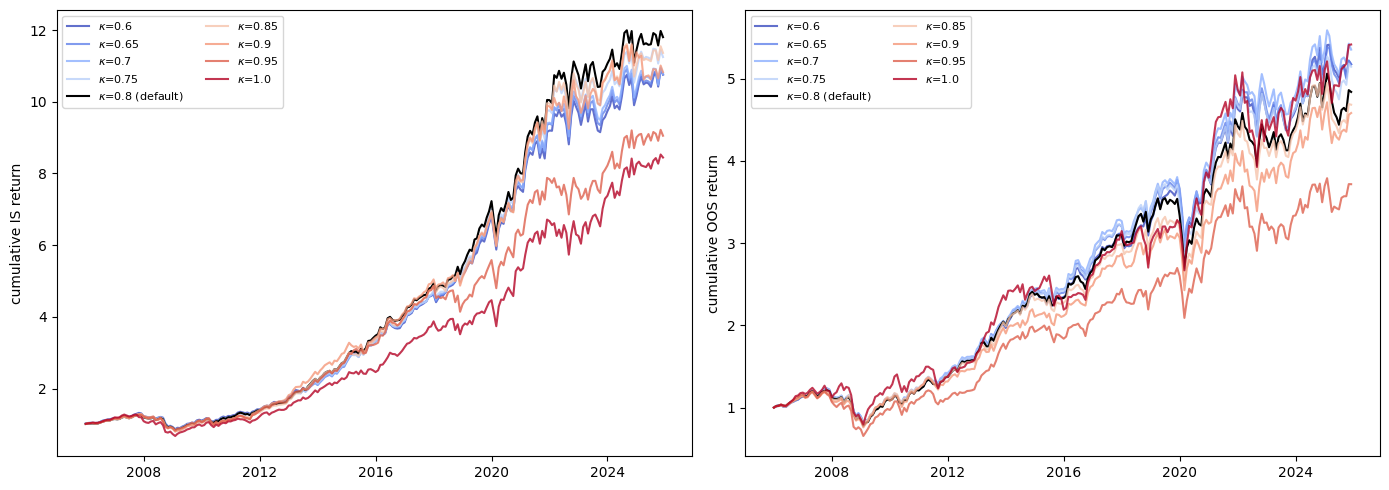

In [5]:
# Rg cumulative IS vs OOS across kappa.
# Diverging coolwarm: κ < default = cool (blue), κ > default = warm (red).
# Default κ (RG_SELECT_SCALE) plotted in bold black on top.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.get_cmap("coolwarm")
kappa_list = list(rg_ts.keys())
kappa_arr = np.array(kappa_list, dtype=float)
norm = plt.Normalize(vmin=kappa_arr.min(), vmax=kappa_arr.max())

for ax, (col_name, ylabel) in zip(
    axes,
    [("ret_ex_is",  "cumulative IS return"),
     ("ret_ex_oos", "cumulative OOS return")],
):
    for kappa in kappa_list:
        df = rg_ts[kappa]
        dt = pd.to_datetime(df["ym"].astype(str), format="%Y%m")
        cum = (1 + df[col_name].fillna(0)).cumprod()
        is_default = abs(kappa - RG_SELECT_SCALE) < 1e-9
        if is_default:
            ax.plot(dt.values, cum.values, color="black", lw=1.5, zorder=10,
                    label=fr"$\kappa$={kappa} (default)")
        else:
            ax.plot(dt.values, cum.values, color=cmap(norm(kappa)),
                    lw=1.5, alpha=0.8, zorder=10,
                    label=fr"$\kappa$={kappa}")
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.savefig(Path(plot_path) / "robustness_shrink_coef.pdf", bbox_inches="tight", dpi=300)
plt.show()